In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mis_dro.plot import flexible_figure

In [12]:
experiment_dir = Path("/dcs/large/u1508153/misdro/compare_solve")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
with open(experiment_dir / "experiment.json", "r") as json_file:
    experiment = json.load(json_file)

# check the number of train/test observations is the same:
assert len(results_df["num_observations"].unique()) == 1
assert len(results_df["num_test_observations"].unique()) == 1

results_df

mean_cost    var_cost  \
uuid                                 replication                          
177ae6b1-1bb3-4796-b6ab-4f6ea7b8b50f 0            31.737600  792.136845   
                                     1            32.018918  763.547684   
                                     2            28.380455  543.840421   
                                     3            30.397329  656.297858   
                                     4            32.983398  225.071533   
...                                                     ...         ...   
fab077f3-96ba-4e09-81bb-83decee4bf59 195          33.920901  714.673887   
                                     196          44.049199  427.992108   
                                     197          33.936538  699.173835   
                                     198          37.763509  373.179092   
                                     199          45.683632  535.972877   

                                                   solution  dgp_time  \
uuid                                 replication                        
177ae6b1-1bb3-4796-b6ab-4f6ea7b8b50f 0            17.364979  0.000823   
                                     1            15.914311  0.001229   
                                     2            15.320911  0.000822   
                                     3            15.229921  0.000676   
                                     4            21.687814  0.000698   
...                                                     ...       ...   
fab077f3-96ba-4e09-81bb-83decee4bf59 195          16.575447  0.000644   
                                     196          24.698542  0.000537   
                                     197          21.943994  0.000597   
                                     198          23.221725  0.000599   
                                     199          28.444185  0.000650   

                                                  likelihood_time  \
uuid                                 replication                    
177ae6b1-1bb3-4796-b6ab-4f6ea7b8b50f 0                   0.007205   
                                     1                   0.007106   
                                     2                   0.007167   
                                     3                   0.007024   
                                     4                   0.007211   
...                                                           ...   
fab077f3-96ba-4e09-81bb-83decee4bf59 195                 0.000016   
                                     196                 0.000016   
                                     197                 0.000017   
                                     198                 0.000017   
                                     199                 0.000024   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
177ae6b1-1bb3-4796-b6ab-4f6ea7b8b50f 0                  0.000150    5.075464   
                                     1                  0.000236    4.865398   
                                     2                  0.000168    4.737583   
                                     3                  0.000135    4.721603   
                                     4                  0.000143    4.654109   
...                                                          ...         ...   
fab077f3-96ba-4e09-81bb-83decee4bf59 195                0.000081    0.014669   
                                     196                0.000056    0.013104   
                                     197                0.000059    0.012126   
                                     198                0.000064    0.012130   
                                     199                0.000080    0.011888   

                                                  setup_time    algorithm  \
uuid                                 replication                            
177ae6b1-1bb3-4796-b6ab-4f6ea7b

In [13]:
gb = results_df.groupby(by=["algorithm", "dgp", "epsilon", "inference", "posterior"])
agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "setup_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"],
})
agg_df

mean_cost  \
                                                                        mean   
algorithm        dgp              epsilon inference posterior                  
bdro_grid_search truncated_normal 0.001   bayes     gamma          32.167064   
                                                    normal_gamma   32.121660   
                                  0.010   bayes     gamma          32.374657   
                                                    normal_gamma   32.223308   
                                  0.100   bayes     gamma          36.294686   
                                                    normal_gamma   32.705245   
                                  1.000   bayes     gamma          78.225302   
                                                    normal_gamma   35.362477   
                                  10.000  bayes     gamma         109.304345   
                                                    normal_gamma   40.087458   
                                  100.000 bayes     gamma         109.304345   
                                                    normal_gamma   40.087458   
kl_bdro          truncated_normal 0.001   bayes     gamma          32.167574   
                                                    normal_gamma   32.121150   
                                  0.010   bayes     gamma          32.374876   
                                                    normal_gamma   32.223757   
                                  0.100   bayes     gamma          36.295727   
                                                    normal_gamma   32.705232   
                                  1.000   bayes     gamma          78.225622   
                                                    normal_gamma   35.362887   
                                  10.000  bayes     gamma         109.303068   
                                                    normal_gamma   40.082829   
                                  100.000 bayes     gamma         109.303063   
                                                    normal_gamma   40.082828   
kl_dro_bas      truncated_normal 0.001   bayes     normal_gamma   32.498116   
                                  0.010   bayes     normal_gamma   33.240692   
                                  0.100   bayes     normal_gamma   36.471710   
                                  1.000   bayes     normal_gamma   36.221596   
                                  10.000  bayes     normal_gamma   36.221596   
                                  100.000 bayes     normal_gamma   36.221597   

                                                                              \
                                                                         var   
algorithm        dgp              epsilon inference posterior                  
bdro_grid_search truncated_normal 0.001   bayes     gamma          20.618567   
                                                    normal_gamma   16.838443   
                                  0.010   bayes     gamma          20.012830   
                                                    normal_gamma   16.955209   
                                  0.100   bayes     gamma          37.960913   
                                                    normal_gamma   18.219628   
                                  1.000   bayes     gamma         228.010074   
                                                    normal_gamma   29.605642   
                                  10.000  bayes     gamma          50.003047   
                                                    normal_gamma   52.890994   
                                  100.000 bayes     gamma          50.003047   
                                                    normal_gamma   52.890994   
kl_bdro          truncated_normal 0.001   bayes     gamma          20.580814   
                                                    normal_gamma   16.831896   
                                  0.010   bayes     gamma          

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

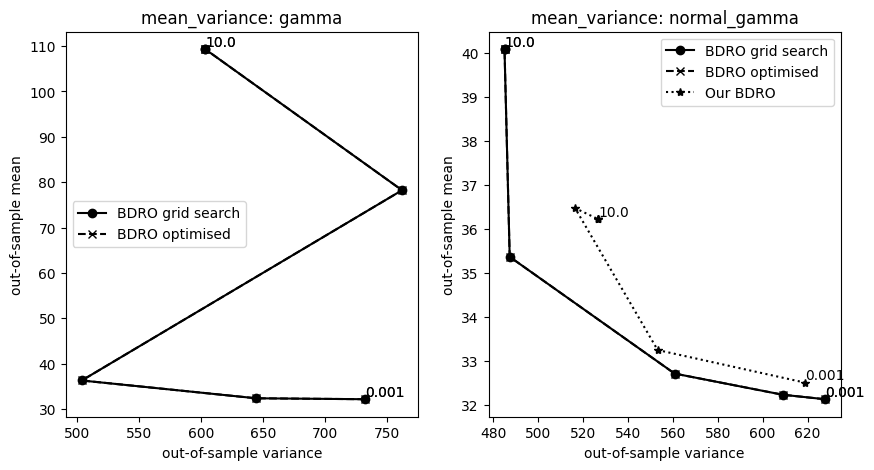

In [14]:
fig, axes = flexible_figure(agg_df, "mean_variance", gb_col="posterior", ncols=2)
fig.show()

## Solve time

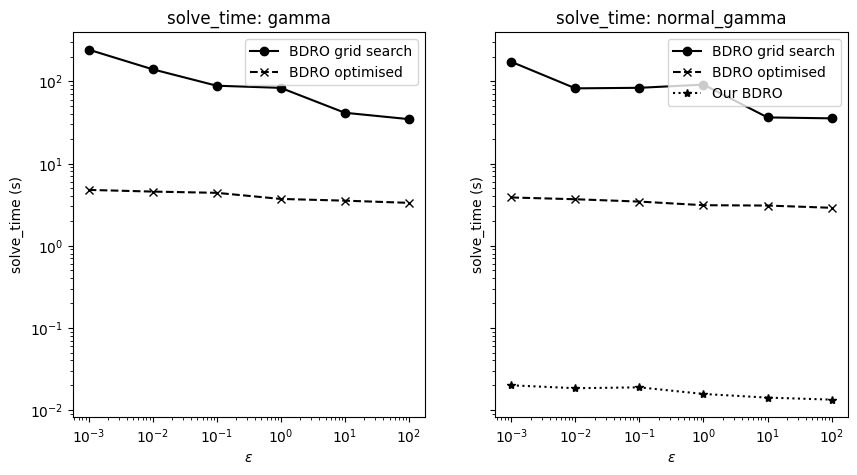

In [15]:
fig, axes = flexible_figure(agg_df, "solve_time", gb_col="posterior", sharex=True, sharey=True, ncols=2)
fig.show()